# Lab 04 - Predictive Modeling Regression

## Data Story

We are helping a real estate team estimate house prices.

Business question:

**Can property features help us predict house price?**

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [4]:
df = pd.read_csv("dataset/House Price Prediction Dataset.csv")
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


## 1. Understand the Dataset

In [5]:
print("Rows and columns:", df.shape)
display(df.info())
display(df.describe(include="all").T)

Rows and columns: (2000, 10)
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 156.4 KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,2000.0,NaN,NaN,NaN,1000.5,577.494589,1.0,500.75,1000.5,1500.25,2000.0
Area,2000.0,NaN,NaN,NaN,2786.2095,1295.146799,501.0,1653.0,2833.0,3887.5,4999.0
Bedrooms,2000.0,NaN,NaN,NaN,3.0035,1.424606,1.0,2.0,3.0,4.0,5.0
Bathrooms,2000.0,NaN,NaN,NaN,2.5525,1.10899,1.0,2.0,3.0,4.0,4.0
Floors,2000.0,NaN,NaN,NaN,1.9935,0.809188,1.0,1.0,2.0,3.0,3.0
YearBuilt,2000.0,NaN,NaN,NaN,1961.446,35.926695,1900.0,1930.0,1961.0,1993.0,2023.0
Location,2000,4,Downtown,558,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Condition,2000,4,Fair,521,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Garage,2000,2,No,1038,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,2000.0,NaN,NaN,NaN,537676.855,276428.845719,50005.0,300098.0,539254.0,780086.0,999656.0


## 2. Visual Story

Area and price are usually connected. Let us check the evidence.

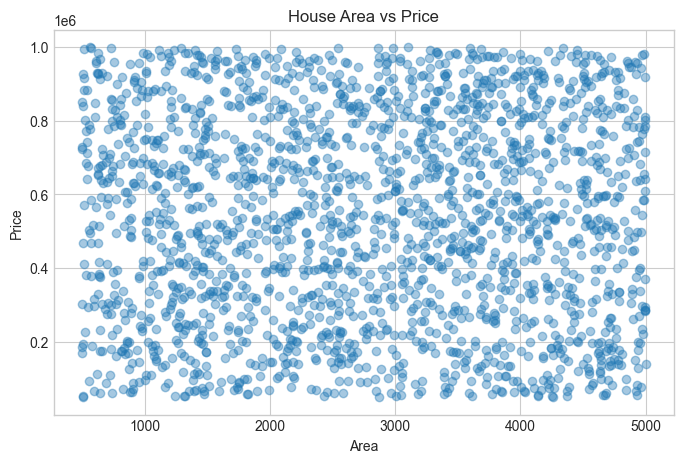

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Area"], df["Price"], alpha=0.4)
plt.title("House Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

## 3. Prepare Data for Regression

In [7]:
X = df.drop(columns=["Id", "Price"])
y = df["Price"]

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 1600
Testing rows: 400


## 4. Train and Evaluate Model

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", round(mae, 2))
print("R2 Score:", round(r2, 3))

Mean Absolute Error: 243241.98
R2 Score: -0.007


## 5. Prediction Story

Compare actual prices and predicted prices.

In [9]:
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predictions,
    "Error": y_test.values - predictions
})

results.head(10)

,Actual Price,Predicted Price,Error
0,514764,521988.221898,-7224.221898
1,694256,549119.311967,145136.688033
2,66375,487101.222356,-420726.222356
3,650243,539752.743993,110490.256007
4,223285,553242.248725,-329957.248725
5,468127,521375.920258,-53248.920258
6,513002,523320.180806,-10318.180806
7,911525,578133.643533,333391.356467
8,723265,545899.647385,177365.352615
9,339416,577368.699406,-237952.699406


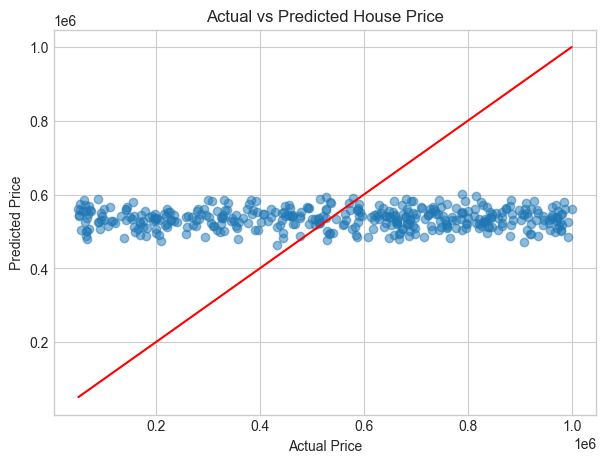

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(results["Actual Price"], results["Predicted Price"], alpha=0.5)
plt.plot([results["Actual Price"].min(), results["Actual Price"].max()],
         [results["Actual Price"].min(), results["Actual Price"].max()],
         color="red")
plt.title("Actual vs Predicted House Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

## 6. Data Storytelling Conclusion

In [11]:
print(f"Story conclusion: The model predicts house prices with an average error of about {mae:,.0f}.")
print(f"R2 score is {r2:.2f}, which tells us how much price variation the model explains.")
print("Business action: use this as an early estimate, then improve with location quality, market trend, and property condition details.")

Story conclusion: The model predicts house prices with an average error of about 243,242.
R2 score is -0.01, which tells us how much price variation the model explains.
Business action: use this as an early estimate, then improve with location quality, market trend, and property condition details.
